# Conditional inverse blocking, exact corrections, and efficiency


## Conventions and statistical split

- Fine chains 0--1 train the flow, chain 2 selects the checkpoint, and chain 3
  is held out for every result shown here.
- The flow order is $d_{01}\to d_{10}\to d_{11}$ with six checkerboard affine
  couplings per sector.
- One MH sweep visits four residue classes for coarse and then for each of the
  three physical detail sectors. The flow is never used after sweep zero.
- A run is labelled converged only when RMS standardized shift $\leq0.20$,
  maximum shift $\leq0.50$, and Binder, $\xi/L$, and scaled susceptibility all
  agree within the combined bootstrap $2\sigma$ interval.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from rgflow.phi4.action import Phi4Action
from rgflow.phi4.blocking import apply_kernel, inverse_kernel
from rgflow.phi4.inverse_blocking import assemble_details, extract_details
from rgflow.phi4.operator_diagnostics import (
    KERNEL_OBSERVABLE_NAMES,
    bootstrap_ensemble_observables,
    kernel_observable_series,
)

plt.rcParams.update({"figure.dpi": 115, "axes.grid": True, "grid.alpha": 0.25})
ACTION = Phi4Action()
KERNEL_META = json.loads((ROOT / "artifacts/phi4/kernel/multivolume_sos2_k0.340301/kernel.json").read_text())
KERNEL = np.asarray(KERNEL_META["matrix"], dtype=np.float64)

MAPPINGS = {
    "L8→L16": {
        "coarse": 8,
        "fine": 16,
        "flow": ROOT / "artifacts/phi4/flow/L8_to_L16_affine",
        "mh": ROOT / "artifacts/phi4/upscale/L8_to_L16_affine_mh",
    },
    "L16→L32": {
        "coarse": 16,
        "fine": 32,
        "flow": ROOT / "artifacts/phi4/flow/L16_to_L32_affine",
        "mh": ROOT / "artifacts/phi4/upscale/L16_to_L32_affine_mh",
    },
}

def native_path(size):
    return ROOT / f"artifacts/2dphi4/phi4_L{size}_k0.340301_lam1.npz"

def load_native(size):
    with np.load(native_path(size)) as data:
        return np.asarray(data["configurations"], dtype=np.float64)

def scalar_metrics(generated, native):
    g = kernel_observable_series(generated, ACTION)
    n = kernel_observable_series(native, ACTION)
    shifts = []
    for name in KERNEL_OBSERVABLE_NAMES:
        pooled = np.sqrt(0.5 * (np.var(g[name], ddof=1) + np.var(n[name], ddof=1)))
        shifts.append((np.mean(g[name]) - np.mean(n[name])) / pooled)
    shifts = np.asarray(shifts)
    return float(np.sqrt(np.mean(shifts**2))), float(np.max(np.abs(shifts)))

DATA = {}
for label, paths in MAPPINGS.items():
    flow_metrics = json.loads((paths["flow"] / "metrics.json").read_text())
    mh_metrics = json.loads((paths["mh"] / "metrics.json").read_text())
    acceptance = json.loads((paths["mh"] / "acceptance_history.json").read_text())
    with np.load(paths["mh"] / "checkpoints/checkpoint_sweep_0000.npz") as state:
        sweep0 = {key: np.asarray(state[key]) for key in state.files}
    with np.load(paths["mh"] / "checkpoints/checkpoint_sweep_0400.npz") as state:
        final = {key: np.asarray(state[key]) for key in state.files}
    native = load_native(paths["fine"])[3]
    normalization = flow_metrics["normalization"]
    rng = np.random.default_rng(7100 + paths["fine"])
    detail_mean = np.asarray(normalization["detail_mean"])[None, :, None, None]
    detail_std = np.asarray(normalization["detail_std"])[None, :, None, None]
    gaussian_details = rng.normal(size=sweep0["details"].shape) * detail_std + detail_mean
    gaussian_psi = assemble_details(sweep0["coarse"], gaussian_details)
    gaussian_fine = inverse_kernel(gaussian_psi, KERNEL)
    target_psi = apply_kernel(native, KERNEL)
    _, target_details = extract_details(target_psi)
    DATA[label] = {
        "paths": paths, "flow_metrics": flow_metrics, "mh_metrics": mh_metrics,
        "acceptance": acceptance, "sweep0": sweep0, "final": final,
        "native": native, "gaussian_fine": gaussian_fine,
        "gaussian_details": gaussian_details, "target_details": target_details,
    }

print("Loaded", ", ".join(DATA), "from", ROOT)

Loaded L8→L16, L16→L32 from /home/jinchen/git/fnal/RGflow


## 1. Flow training and numerical invertibility

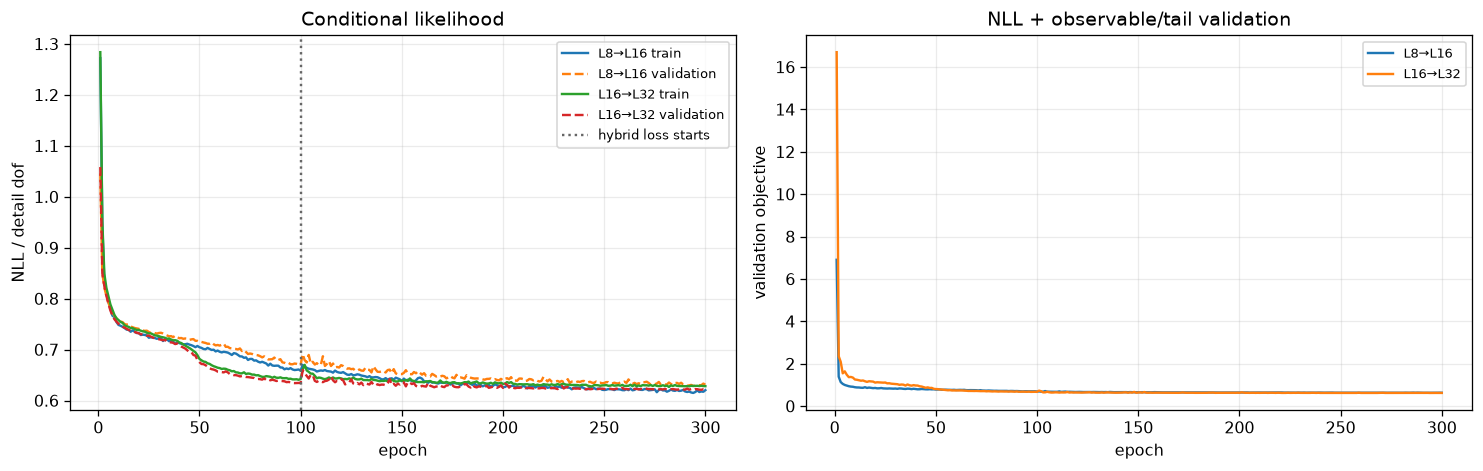

mapping      best   test RMS   latent err   logdet err
L8→L16        294     0.3516     2.95e-06     1.53e-05
L16→L32       278     0.6046     3.58e-06     6.10e-05


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for label, data in DATA.items():
    history = data["flow_metrics"]["history"]
    epoch = np.asarray([row["epoch"] for row in history])
    axes[0].plot(epoch, [row["training_nll"] for row in history], label=f"{label} train")
    axes[0].plot(epoch, [row["validation_nll"] for row in history], "--", label=f"{label} validation")
    axes[1].plot(epoch, [row["validation_total"] for row in history], label=label)
axes[0].axvline(100, color="0.4", linestyle=":", label="hybrid loss starts")
axes[0].set(xlabel="epoch", ylabel="NLL / detail dof", title="Conditional likelihood")
axes[1].set(xlabel="epoch", ylabel="validation objective", title="NLL + observable/tail validation")
for axis in axes: axis.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"{'mapping':<10} {'best':>6} {'test RMS':>10} {'latent err':>12} {'logdet err':>12}")
for label, data in DATA.items():
    metric = data["flow_metrics"]
    rt = metric["roundtrip"]
    print(f"{label:<10} {metric['best_epoch']:>6d} {metric['test']['rms_standardized_shift']:>10.4f} "
          f"{rt['latent_max_abs_error']:>12.2e} {rt['logdet_max_abs_error']:>12.2e}")

The larger mapping has a visibly harder sweep-zero distribution. Both trained maps remain numerically invertible at float32 precision.

## 2. What the flow learns before MH

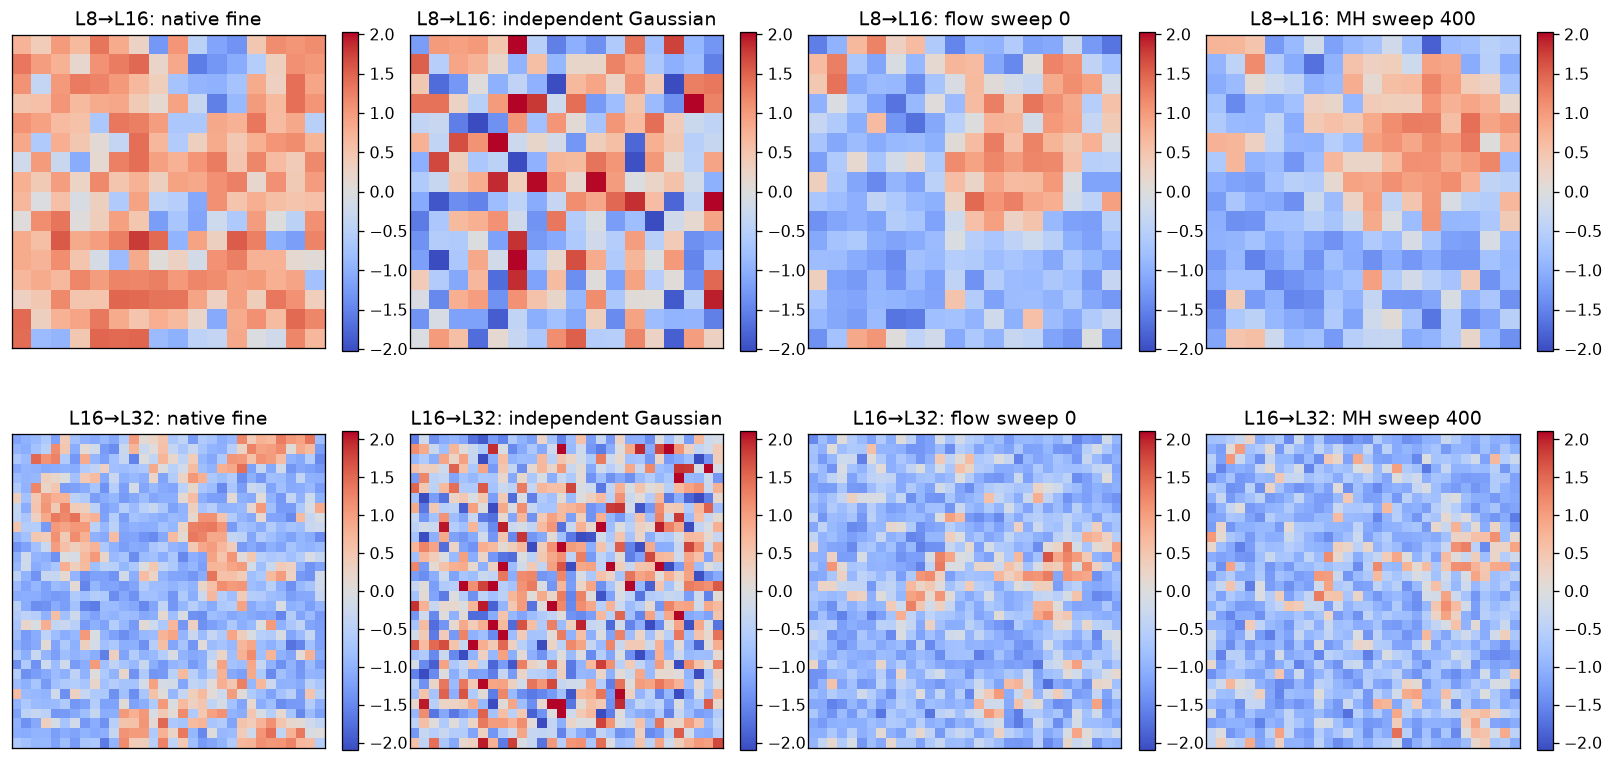

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(14, 7.2))
for row, (label, data) in enumerate(DATA.items()):
    fields = [
        data["native"][0], data["gaussian_fine"][0],
        data["sweep0"]["fine"][0], data["final"]["fine"][0],
    ]
    titles = ["native fine", "independent Gaussian", "flow sweep 0", "MH sweep 400"]
    limit = np.quantile(np.abs(np.concatenate([field.ravel() for field in fields])), 0.99)
    for column, (field, title) in enumerate(zip(fields, titles)):
        image = axes[row, column].imshow(field, cmap="coolwarm", vmin=-limit, vmax=limit)
        axes[row, column].set_title(f"{label}: {title}")
        axes[row, column].set_xticks([]); axes[row, column].set_yticks([])
        fig.colorbar(image, ax=axes[row, column], fraction=0.046)
fig.tight_layout()
plt.show()

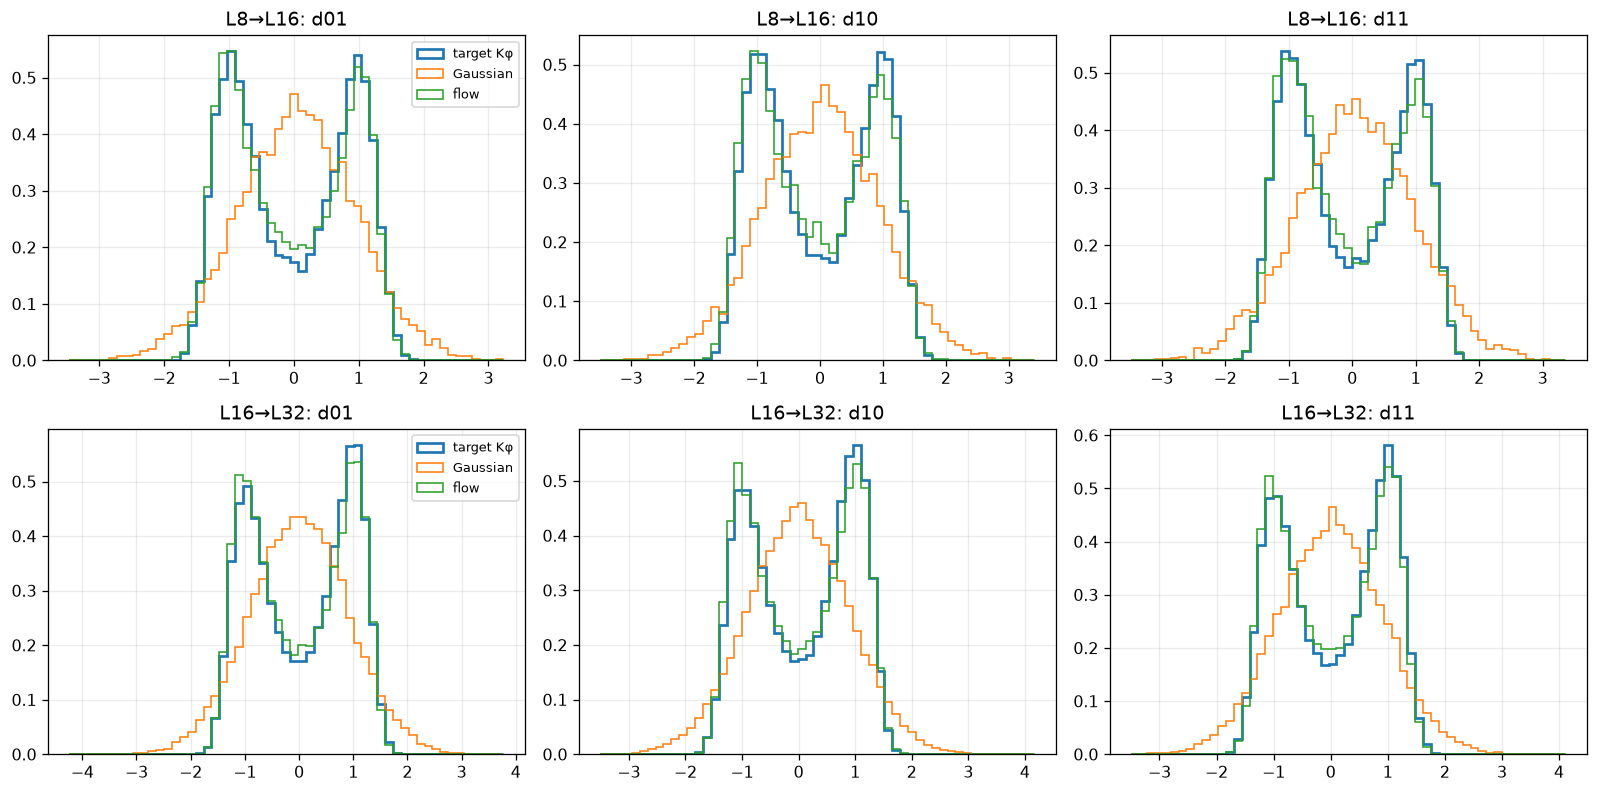

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
names = ("d01", "d10", "d11")
for row, (label, data) in enumerate(DATA.items()):
    for sector, name in enumerate(names):
        axis = axes[row, sector]
        values = np.concatenate((
            data["target_details"][:, sector].ravel(),
            data["gaussian_details"][:, sector].ravel(),
            data["sweep0"]["details"][:, sector].ravel(),
        ))
        bins = np.histogram_bin_edges(values, bins=55)
        axis.hist(data["target_details"][:, sector].ravel(), bins=bins, density=True, histtype="step", linewidth=1.7, label="target Kφ")
        axis.hist(data["gaussian_details"][:, sector].ravel(), bins=bins, density=True, histtype="step", label="Gaussian")
        axis.hist(data["sweep0"]["details"][:, sector].ravel(), bins=bins, density=True, histtype="step", label="flow")
        axis.set_title(f"{label}: {name}")
        if sector == 0: axis.legend(fontsize=8)
fig.tight_layout()
plt.show()

In [5]:
print(f"{'mapping':<10} {'initializer':<20} {'RMS shift':>10} {'max shift':>10}")
for label, data in DATA.items():
    for name, fields in (
        ("Gaussian details", data["gaussian_fine"]),
        ("affine flow sweep 0", data["sweep0"]["fine"]),
        ("exact MH sweep 400", data["final"]["fine"]),
    ):
        rms, maximum = scalar_metrics(fields, data["native"])
        print(f"{label:<10} {name:<20} {rms:>10.4f} {maximum:>10.4f}")

mapping    initializer           RMS shift  max shift
L8→L16     Gaussian details         4.8350     6.9573
L8→L16     affine flow sweep 0      0.3567     1.0097
L8→L16     exact MH sweep 400       0.2158     0.2733
L16→L32    Gaussian details         8.1756    13.3143
L16→L32    affine flow sweep 0      0.5182     1.4713
L16→L32    exact MH sweep 400       0.2043     0.2819


## 3. Observable distributions after exact MH

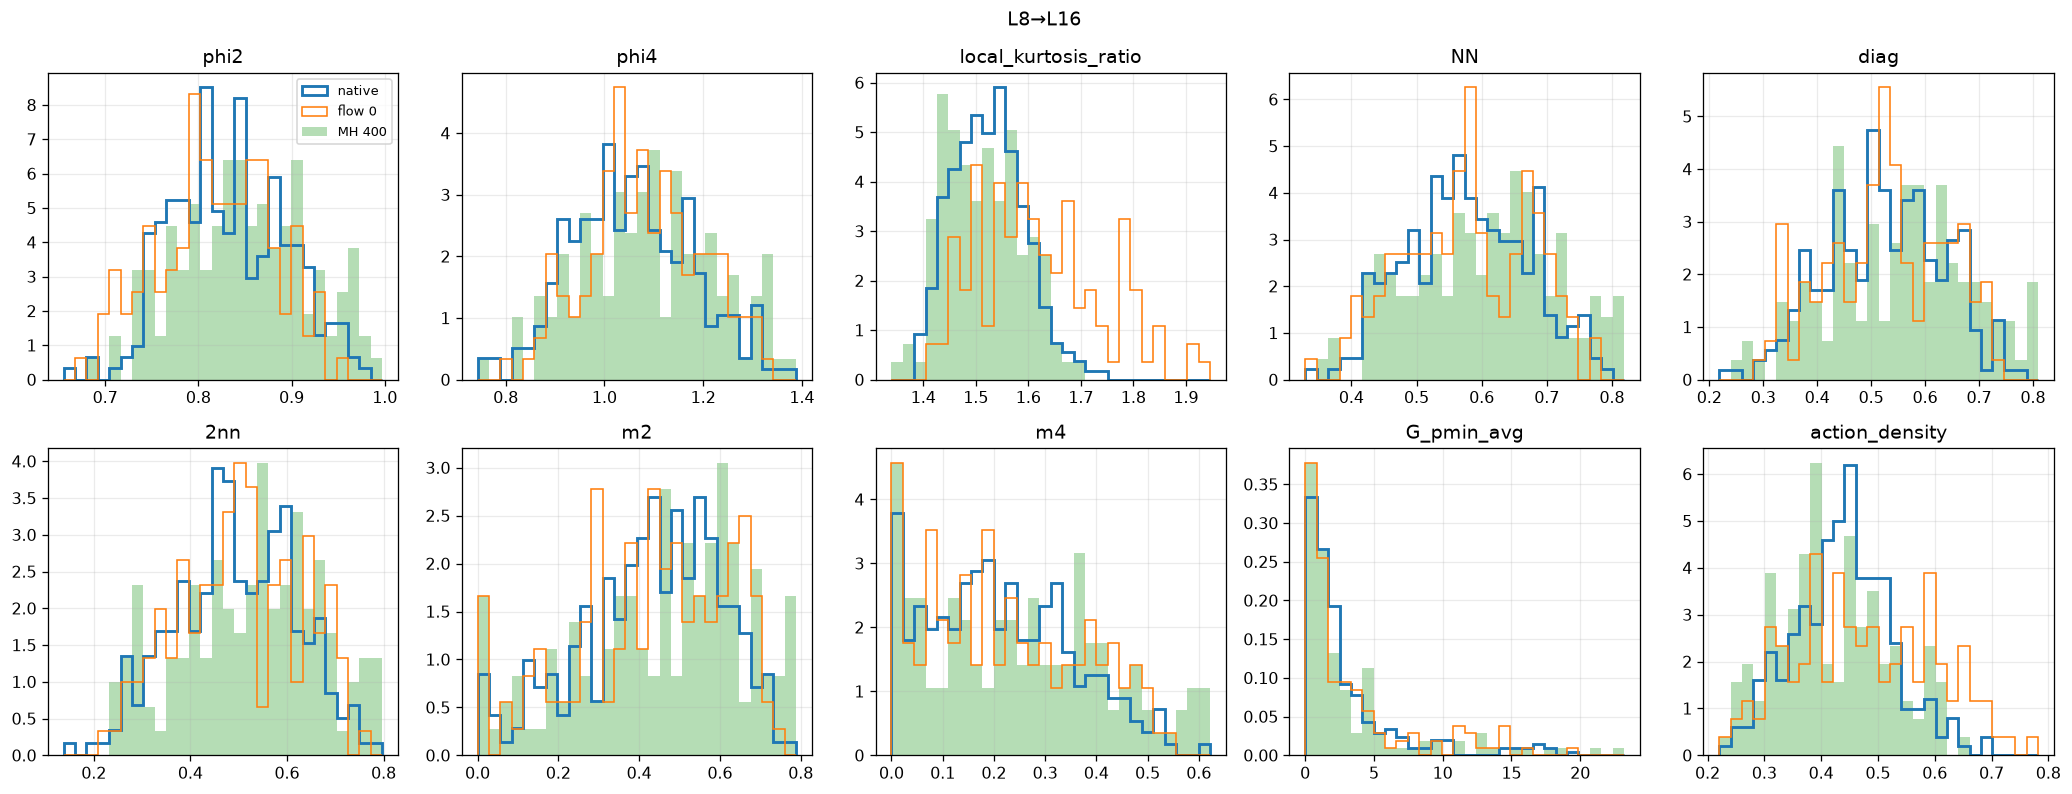

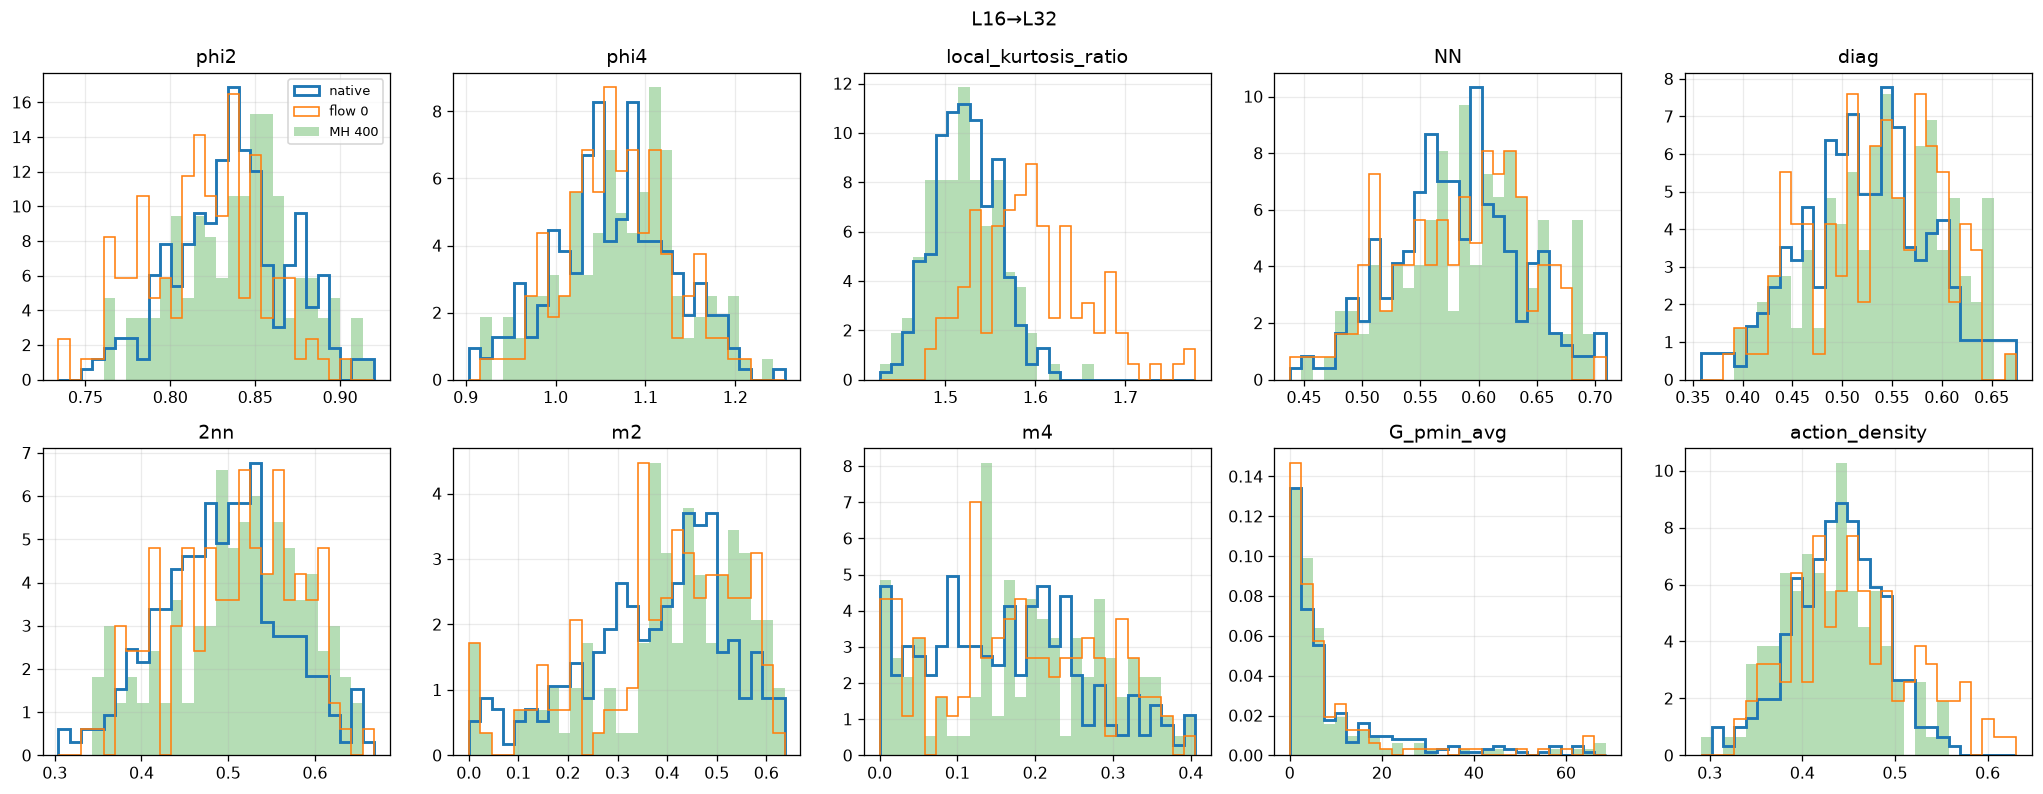

In [6]:
for label, data in DATA.items():
    native_series = kernel_observable_series(data["native"], ACTION)
    initial_series = kernel_observable_series(data["sweep0"]["fine"], ACTION)
    final_series = kernel_observable_series(data["final"]["fine"], ACTION)
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    for axis, name in zip(axes.flat, KERNEL_OBSERVABLE_NAMES):
        combined = np.concatenate((native_series[name], initial_series[name], final_series[name]))
        bins = np.histogram_bin_edges(combined, bins=28)
        axis.hist(native_series[name], bins=bins, density=True, histtype="step", linewidth=1.8, label="native")
        axis.hist(initial_series[name], bins=bins, density=True, histtype="step", label="flow 0")
        axis.hist(final_series[name], bins=bins, density=True, alpha=0.35, label="MH 400")
        axis.set_title(name)
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(label)
    fig.tight_layout()
    plt.show()

## 4. Rethermalization trajectories

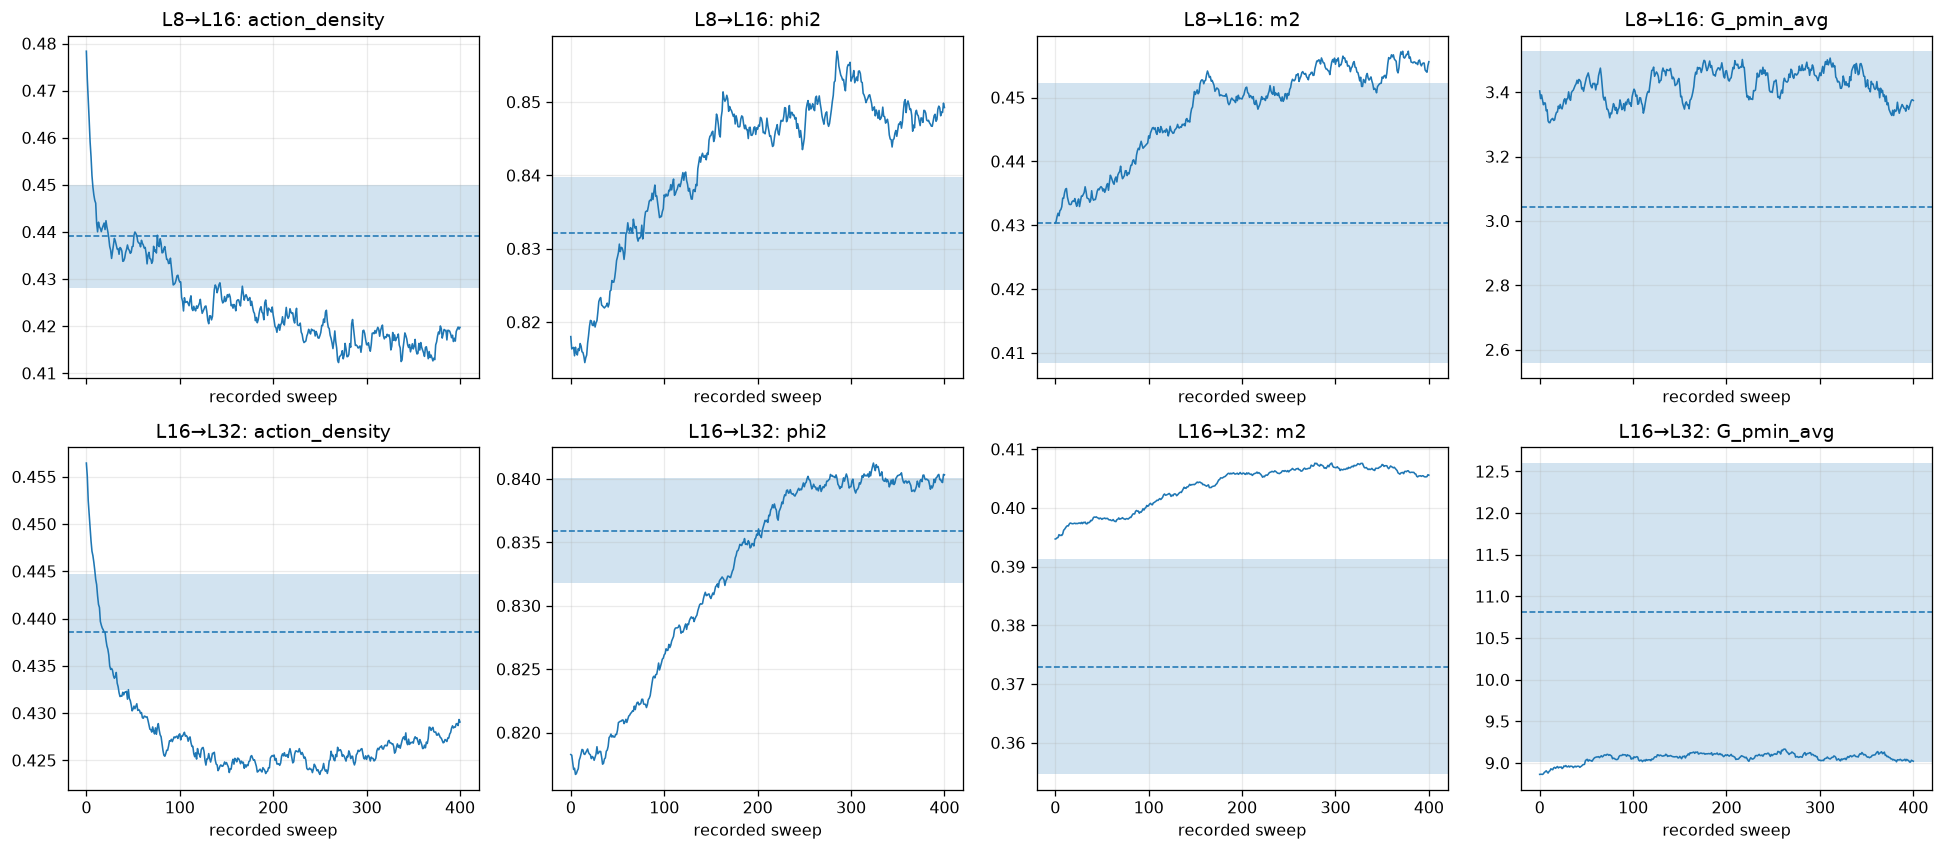

In [7]:
selected = ("action_density", "phi2", "m2", "G_pmin_avg")
fig, axes = plt.subplots(2, 4, figsize=(17, 7.5), sharex=True)
for row, (label, data) in enumerate(DATA.items()):
    history = data["mh_metrics"]["history"]
    sweeps = np.asarray([item["sweep"] for item in history])
    native_series = kernel_observable_series(data["native"], ACTION)
    for column, name in enumerate(selected):
        values = np.asarray([item["observables"][name] for item in history])
        target = np.mean(native_series[name])
        error = 2.0 * np.std(native_series[name], ddof=1) / np.sqrt(len(native_series[name]))
        axes[row, column].plot(sweeps, values, linewidth=1)
        axes[row, column].axhspan(target - error, target + error, alpha=0.2)
        axes[row, column].axhline(target, linestyle="--", linewidth=1)
        axes[row, column].set_title(f"{label}: {name}")
        axes[row, column].set_xlabel("recorded sweep")
fig.tight_layout()
plt.show()

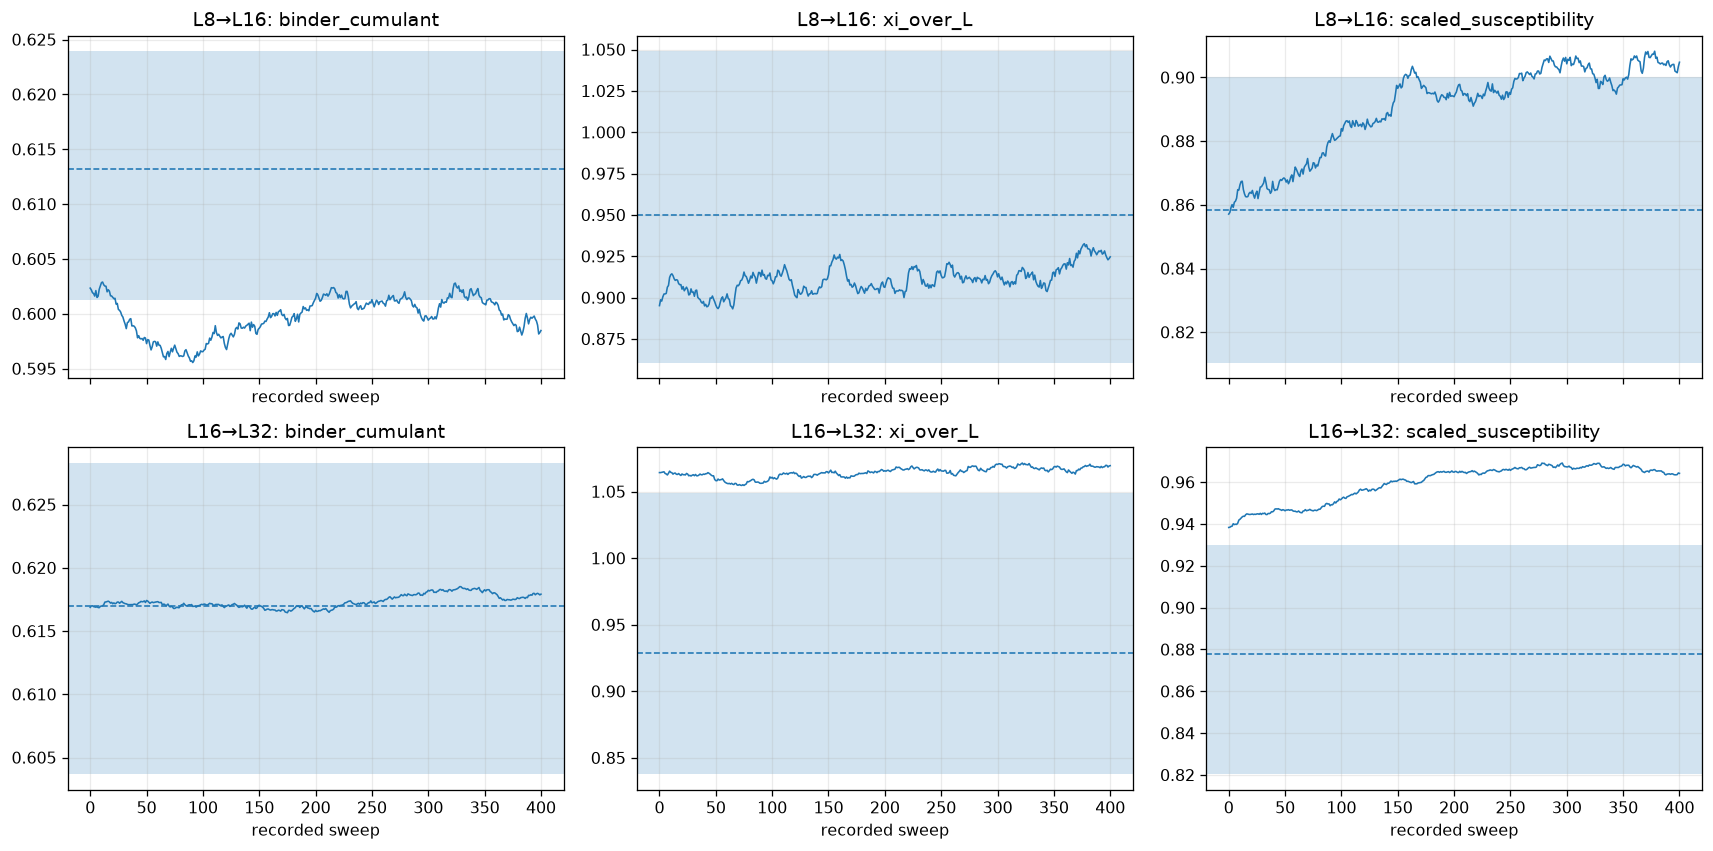

In [8]:
physical_names = ("binder_cumulant", "xi_over_L", "scaled_susceptibility")
fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharex=True)
for row, (label, data) in enumerate(DATA.items()):
    history = data["mh_metrics"]["history"]
    sweeps = np.asarray([item["sweep"] for item in history])
    bootstrap = bootstrap_ensemble_observables(data["native"][None], samples=1000, block_length=2, seed=8200 + row)
    for column, name in enumerate(physical_names):
        values = np.asarray([item["physical"][name] for item in history])
        source_name = "susceptibility" if name == "scaled_susceptibility" else name
        target_samples = bootstrap[source_name]
        if name == "scaled_susceptibility":
            target_samples = target_samples / data["paths"]["fine"] ** 1.75
        low, center, high = np.nanquantile(target_samples, (0.025, 0.5, 0.975))
        axes[row, column].plot(sweeps, values, linewidth=1)
        axes[row, column].axhspan(low, high, alpha=0.2)
        axes[row, column].axhline(center, linestyle="--", linewidth=1)
        axes[row, column].set_title(f"{label}: {name}")
        axes[row, column].set_xlabel("recorded sweep")
fig.tight_layout()
plt.show()

## 5. Exact-update diagnostics

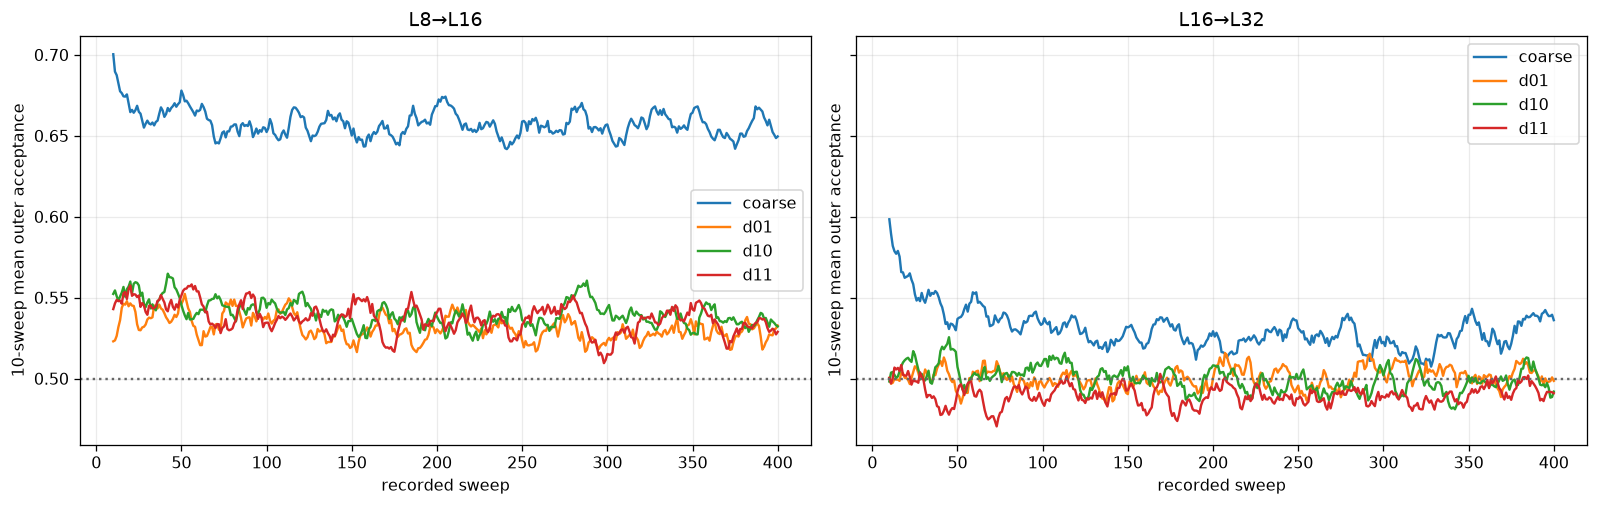

mapping     coarse width       d01       d10       d11    max reblock
L8→L16           0.20000   0.09992   0.09771   0.09824       1.55e-15
L16→L32          0.12594   0.05217   0.05217   0.05407       1.78e-15


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
for axis, (label, data) in zip(axes, DATA.items()):
    sweeps = np.arange(1, len(data["acceptance"]) + 1)
    for name in ("coarse", "d01", "d10", "d11"):
        rates = np.asarray([item["coordinates"][name]["outer_acceptance"] for item in data["acceptance"]])
        smooth = np.convolve(rates, np.ones(10) / 10, mode="valid")
        axis.plot(sweeps[9:], smooth, label=name)
    axis.axhline(0.5, linestyle=":", color="0.4")
    axis.set(xlabel="recorded sweep", ylabel="10-sweep mean outer acceptance", title=label)
    axis.legend()
fig.tight_layout()
plt.show()

print(f"{'mapping':<10} {'coarse width':>13} {'d01':>9} {'d10':>9} {'d11':>9} {'max reblock':>14}")
for label, data in DATA.items():
    widths = data["mh_metrics"]["run_config"]["proposal_widths"]
    maximum = max(item["max_reblocking_error"] for item in data["acceptance"])
    print(f"{label:<10} {widths['coarse']:>13.5f} {widths['d01']:>9.5f} {widths['d10']:>9.5f} {widths['d11']:>9.5f} {maximum:>14.2e}")

## 6. Convergence decision at sweep 400

In [10]:
print(f"{'mapping':<10} {'status':<18} {'RMS':>8} {'max':>8} {'Binder 2σ':>10} {'xi/L 2σ':>9} {'chi 2σ':>8}")
for label, data in DATA.items():
    convergence = data["mh_metrics"]["convergence"]
    checks = convergence["physical_checks"]
    status = "PASS" if convergence["converged"] else "EXTEND CHAIN"
    print(f"{label:<10} {status:<18} {convergence['rms_standardized_mean_shift']:>8.4f} "
          f"{convergence['max_abs_standardized_mean_shift']:>8.4f} "
          f"{str(checks['binder_cumulant']['within_2sigma']):>10} "
          f"{str(checks['xi_over_L']['within_2sigma']):>9} "
          f"{str(checks['scaled_susceptibility']['within_2sigma']):>8}")

display(Markdown(
    "Both exact chains pass all three physical $2\\sigma$ checks and the maximum-shift "
    "criterion, but their RMS shifts are 0.2158 and 0.2043, just above the fixed 0.20 "
    "threshold. They are therefore retained as exact-MH finite-chain ensembles and "
    "explicitly labelled **not yet rethermalized by the predeclared criterion**."
))

mapping    status                  RMS      max  Binder 2σ   xi/L 2σ   chi 2σ
L8→L16     EXTEND CHAIN         0.2158   0.2733       True      True     True
L16→L32    EXTEND CHAIN         0.2043   0.2819       True      True     True


Both exact chains pass all three physical $2\sigma$ checks and the maximum-shift criterion, but their RMS shifts are 0.2158 and 0.2043, just above the fixed 0.20 threshold. They are therefore retained as exact-MH finite-chain ensembles and explicitly labelled **not yet rethermalized by the predeclared criterion**.

## 7. Historical `temp/Inverse_RG` reference

The curated reference tree contains code, its final kernel, and the following
documented acceptance summaries, but deliberately omits trained checkpoints and
run products. These numbers are context rather than an apples-to-apples ranking:
the reference uses a different kernel, wrapped RQ-spline flow, and latent-space
proposals, whereas this notebook uses the current SOS kernel, an affine flow,
and physical-coordinate updates.

| Reference update | Mapping | Coarse / global | d01 | d10 | d11 |
|---|---:|---:|---:|---:|---:|
| Global independence MH | L8→L16 | 17.42% | — | — | — |
| Global independence MH | L16→L32 | 1.646% | — | — | — |
| Four independent latent substeps | L8→L16 | 22.0% | 44.625% | 43.75% | 46.375% |
| Coarse-MH + latent substeps | L16→L32 | 59.18% | 19.73% | 17.97% | 19.53% |
| Preliminary divide-2 latent substeps | L16→L32 | 45.64% | 38.80% | 40.10% | 42.19% |

Source: `temp/Inverse_RG/perfect_blocking_upsampling/docs/mit_style_update_evolution_20260722.md`.

## Reproducibility

```bash
uv sync --extra test --extra flow --extra presentation
.venv/bin/rgflow train flow phi4 --device cuda
.venv/bin/rgflow upscale phi4 \
  --checkpoint artifacts/phi4/flow/L8_to_L16_affine/checkpoint.pt \
  --coarse artifacts/2dphi4/phi4_L8_k0.340301_lam1.npz \
  --native-fine artifacts/2dphi4/phi4_L16_k0.340301_lam1.npz \
  --output artifacts/phi4/upscale/L8_to_L16_affine_mh --device cuda
.venv/bin/rgflow upscale phi4 \
  --checkpoint artifacts/phi4/flow/L16_to_L32_affine/checkpoint.pt \
  --coarse artifacts/2dphi4/phi4_L16_k0.340301_lam1.npz \
  --native-fine artifacts/2dphi4/phi4_L32_k0.340301_lam1.npz \
  --output artifacts/phi4/upscale/L16_to_L32_affine_mh --device cuda --seed 20260825
.venv/bin/python presentation/build_flow_inverse_blocking_notebook.py --execute
```

## 8. Optimized correction kernels and efficiency benchmark

The production comparison now treats the three detail cosets as UV-rich transformed coordinates, not physical links. Detail/amplitude MH repairs short-distance structure, while one fine-field Wolff update per chain and sweep repairs sign clusters and infrared magnetization modes. HMC is a single-seed control and advances only if it wins both thermalization time and worst-observable ESS/s. The cell below reads the newest versioned benchmark artifact; run 'rgflow benchmark phi4' to populate it.


In [11]:
benchmark_root = ROOT / "artifacts/phi4/benchmark"
summaries = sorted(benchmark_root.glob("*/summary.json")) if benchmark_root.exists() else []
if not summaries:
    print("No optimized benchmark artifact yet; run rgflow benchmark phi4.")
else:
    benchmark = json.loads(summaries[-1].read_text())
    rows = []
    for mapping, case in benchmark["cases"].items():
        native = case["native"]["efficiency"]["worst_ess_per_second"]
        for method, result in case["methods"].items():
            rows.append((mapping, method, result["time_to_tolerance_sweeps"],
                         result["worst_ess_per_second"],
                         result["efficiency_ratio_to_native"],
                         result["paired_bootstrap_ratio"]["lower_95"]))
    print(f"{'mapping':<12} {'method':<28} {'thermalize':>10} {'worst ESS/s':>13} {'ratio':>8} {'CI low':>8}")
    for row in rows:
        print(f"{row[0]:<12} {row[1]:<28} {str(row[2]):>10} {row[3]:13.2f} {row[4]:8.2f} {row[5]:8.2f}")


mapping      method                       thermalize   worst ESS/s    ratio   CI low
L16_to_L32   coordinate                         None        138.59     0.70     0.60
L16_to_L32   coordinate-wolff                   None         88.97     0.45     0.33
L16_to_L32   detail2-wolff                      None         74.92     0.38     0.27
L16_to_L32   detail2-wolff-gaussian             None         64.72     0.33     0.26
L16_to_L32   detail4-wolff                      None         45.10     0.23     0.17
L16_to_L32   flow-detail2-wolff                 None         55.20     0.28     0.21
L16_to_L32   hmc-wolff                          None        204.89     1.04     0.79
L8_to_L16    coordinate                         None        299.32     0.58     0.44
L8_to_L16    coordinate-wolff                   None        205.67     0.40     0.28
L8_to_L16    detail2-wolff                      None        154.66     0.30     0.23
L8_to_L16    detail2-wolff-gaussian             None        115.9